<a href="https://colab.research.google.com/github/zhaodrago-cell/Project-1/blob/main/note%20book/%203_Extension_and_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Phase 3 Extension: Heterogeneity and Robustness in Card & Krueger (1994)

This notebook extends the baseline replication of Card and Krueger's analysis of the 1992 New Jersey minimum wage increase. The goal is to examine whether the employment effect differed across restaurant chains, ownership types, and geographic areas, and to test whether the main result is robust to alternative employment measures and model specifications.

In [ ]:
## 1. Motivation

Card and Krueger's original study focuses mainly on the average treatment effect of the New Jersey minimum wage increase on fast-food employment. While this average effect is central to the paper, it may conceal important differences across types of restaurants. For example, large chains, franchised stores, or stores in different local labor markets may have responded differently to the policy change.

This extension addresses that limitation by studying treatment heterogeneity across restaurant chains, ownership type, and geographic areas. It also conducts robustness checks using alternative employment measures and model specifications. The main question is whether the baseline conclusion remains stable once we move beyond the average effect.

In [2]:
import os
import shutil
from pathlib import Path

REPO_URL = "https://github.com/zhaodrago-cell/Project-1.git"
ROOT = Path("/content/Project-1")

os.chdir("/content")
if ROOT.exists():
    shutil.rmtree(ROOT)

!git clone {REPO_URL} {ROOT}

print("Repo cloned:", ROOT.exists())
print("Top-level folders/files:")
!ls -la /content/Project-1

Cloning into '/content/Project-1'...
remote: Enumerating objects: 159, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 159 (delta 4), reused 0 (delta 0), pack-reused 151 (from 1)
Receiving objects: 100% (159/159), 118.29 KiB | 5.91 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Repo cloned: True
Top-level folders/files:
total 28
drwxr-xr-x 5 root root 4096 Mar 25 09:48  .
drwxr-xr-x 1 root root 4096 Mar 25 09:48  ..
drwxr-xr-x 4 root root 4096 Mar 25 09:48  Date
drwxr-xr-x 8 root root 4096 Mar 25 09:48  .git
-rw-r--r-- 1 root root  114 Mar 25 09:48  .gitignore
drwxr-xr-x 2 root root 4096 Mar 25 09:48 'note book'
-rw-r--r-- 1 root root 1185 Mar 25 09:48  README.md


In [3]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [4]:
DATA_DIR = ROOT / "Date"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = ROOT / "outputs_phase3"

OUTPUT_DIR.mkdir(exist_ok=True)

processed_path = PROCESSED_DIR / "njmin_public_processed.csv"
dat_path = RAW_DIR / "public.dat"
sas_path = RAW_DIR / "check.sas"

print("DATA_DIR exists:", DATA_DIR.exists(), DATA_DIR)
print("RAW_DIR exists:", RAW_DIR.exists(), RAW_DIR)
print("PROCESSED_DIR exists:", PROCESSED_DIR.exists(), PROCESSED_DIR)
print("processed_path exists:", processed_path.exists(), processed_path)
print("dat_path exists:", dat_path.exists(), dat_path)
print("sas_path exists:", sas_path.exists(), sas_path)

DATA_DIR exists: True /content/Project-1/Date
RAW_DIR exists: True /content/Project-1/Date/raw
PROCESSED_DIR exists: True /content/Project-1/Date/processed
processed_path exists: True /content/Project-1/Date/processed/njmin_public_processed.csv
dat_path exists: True /content/Project-1/Date/raw/public.dat
sas_path exists: True /content/Project-1/Date/raw/check.sas


In [5]:
colspecs = [
    (0,3), (4,5), (6,7), (8,9), (10,11), (12,13), (14,15), (16,17), (18,19), (20,21),
    (22,24), (25,30), (31,36), (37,42), (43,48), (49,54), (55,60), (61,62), (63,68), (69,70),
    (71,76), (77,82), (83,88), (89,94), (95,100), (101,103), (104,106),
    (107,108), (109,110), (111,117), (118,120), (121,126), (127,132), (133,138), (139,144),
    (145,150), (151,156), (157,158), (159,160), (161,166), (167,172), (173,178), (179,184),
    (185,190), (191,193), (194,196)
]

names = [
    "SHEET","CHAIN","CO_OWNED","STATE","SOUTHJ","CENTRALJ","NORTHJ","PA1","PA2","SHORE",
    "NCALLS","EMPFT","EMPPT","NMGRS","WAGE_ST","INCTIME","FIRSTINC","BONUS","PCTAFF","MEALS",
    "OPEN","HRSOPEN","PSODA","PFRY","PENTREE","NREGS","NREGS11",
    "TYPE2","STATUS2","DATE2","NCALLS2","EMPFT2","EMPPT2","NMGRS2","WAGE_ST2",
    "INCTIME2","FIRSTIN2","SPECIAL2","MEALS2","OPEN2R","HRSOPEN2","PSODA2","PFRY2",
    "PENTREE2","NREGS2","NREGS112"
]

df = pd.read_fwf(dat_path, colspecs=colspecs, names=names, na_values=[".", ""])

for c in names:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Raw data shape:", df.shape)
df.head()

Raw data shape: (410, 46)


,SHEET,CHAIN,CO_OWNED,STATE,SOUTHJ,CENTRALJ,NORTHJ,PA1,PA2,SHORE,NCALLS,EMPFT,EMPPT,NMGRS,WAGE_ST,INCTIME,FIRSTINC,BONUS,PCTAFF,MEALS,OPEN,HRSOPEN,PSODA,PFRY,PENTREE,NREGS,NREGS11,TYPE2,STATUS2,DATE2,NCALLS2,EMPFT2,EMPPT2,NMGRS2,WAGE_ST2,INCTIME2,FIRSTIN2,SPECIAL2,MEALS2,OPEN2R,HRSOPEN2,PSODA2,PFRY2,PENTREE2,NREGS2,NREGS112
0,46,1,0,0,0,0,0,1,0,0,0,30.0,15.0,3.0,NaN,19.0,NaN,1,NaN,2,6.5,16.5,1.03,1.03,0.52,3.0,3.0,1,1,111792,1.0,3.5,35.0,3.0,4.30,26.0,0.08,1.0,2.0,6.5,16.5,1.03,NaN,0.94,4.0,4.0
1,49,2,0,0,0,0,0,1,0,0,0,6.5,6.5,4.0,NaN,26.0,NaN,0,NaN,2,10.0,13.0,1.01,0.90,2.35,4.0,3.0,1,1,111292,NaN,0.0,15.0,4.0,4.45,13.0,0.05,0.0,2.0,10.0,13.0,1.01,0.89,2.35,4.0,4.0
2,506,2,1,0,0,0,0,1,0,0,0,3.0,7.0,2.0,NaN,13.0,0.37,0,30.0,2,11.0,10.0,0.95,0.74,2.33,3.0,3.0,1,1,111292,NaN,3.0,7.0,4.0,5.00,19.0,0.25,NaN,1.0,11.0,11.0,0.95,0.74,2.33,4.0,3.0
3,56,4,1,0,0,0,0,1,0,0,0,20.0,20.0,4.0,5.0,26.0,0.10,1,0.0,2,10.0,12.0,0.87,0.82,1.79,2.0,2.0,1,1,111492,NaN,0.0,36.0,2.0,5.25,26.0,0.15,0.0,2.0,10.0,12.0,0.92,0.79,0.87,2.0,2.0
4,61,4,1,0,0,0,0,1,0,0,0,6.0,26.0,5.0,5.5,52.0,0.15,1,0.0,3,10.0,12.0,0.87,0.77,1.65,2.0,2.0,1,1,111492,NaN,28.0,3.0,6.0,4.75,13.0,0.15,0.0,2.0,10.0,12.0,1.01,0.84,0.95,2.0,2.0


In [6]:
df["treat"] = (df["STATE"] == 1).astype(int)

# Full-time-equivalent employment before / after
df["fte1"] = df["EMPFT"] + 0.5 * df["EMPPT"] + df["NMGRS"]
df["fte2"] = df["EMPFT2"] + 0.5 * df["EMPPT2"] + df["NMGRS2"]

# Price index before / after
df["price1"] = df["PSODA"] + df["PFRY"] + df["PENTREE"]
df["price2"] = df["PSODA2"] + df["PFRY2"] + df["PENTREE2"]

# Ownership type
# CO_OWNED == 1 usually means company-owned
df["ownership_type"] = np.where(df["CO_OWNED"] == 1, "Company-owned", "Other/Franchise")

# Region grouping
def make_region(row):
    if row["STATE"] == 0:
        return "PA"
    if row["SHORE"] == 1:
        return "NJ_Shore"
    if row["NORTHJ"] == 1:
        return "NJ_North"
    if row["CENTRALJ"] == 1:
        return "NJ_Central"
    if row["SOUTHJ"] == 1:
        return "NJ_South"
    return "NJ_Other"

df["region_group"] = df.apply(make_region, axis=1)

# Simpler geography split for robustness / heterogeneity
df["coastal"] = np.where(df["SHORE"] == 1, 1, 0)
df["coastal_label"] = np.where(df["coastal"] == 1, "Shore", "Non-Shore")

# Chain labels
chain_map = {
    1: "Burger King",
    2: "KFC",
    3: "Roy Rogers",
    4: "Wendy's"
}
df["chain_label"] = df["CHAIN"].map(chain_map).fillna("Other")

# Alternative employment outcomes
df["emp_total1"] = df["EMPFT"] + df["EMPPT"] + df["NMGRS"]
df["emp_total2"] = df["EMPFT2"] + df["EMPPT2"] + df["NMGRS2"]

# Change measures
df["fte_change"] = df["fte2"] - df["fte1"]
df["price_change"] = df["price2"] - df["price1"]
df["wage_change"] = df["WAGE_ST2"] - df["WAGE_ST"]

print(df[[
    "SHEET","STATE","treat","CHAIN","chain_label","CO_OWNED","ownership_type",
    "region_group","fte1","fte2","emp_total1","emp_total2","price1","price2"
]].head())

   SHEET  STATE  treat  CHAIN  chain_label  CO_OWNED   ownership_type region_group   fte1  fte2  emp_total1  emp_total2  price1  price2
0     46      0      0      1  Burger King         0  Other/Franchise           PA  40.50  24.0        48.0        41.5    2.58     NaN
1     49      0      0      2          KFC         0  Other/Franchise           PA  13.75  11.5        17.0        19.0    4.26    4.25
2    506      0      0      2          KFC         1    Company-owned           PA   8.50  10.5        12.0        14.0    4.02    4.02
3     56      0      0      4      Wendy's         1    Company-owned           PA  34.00  20.0        44.0        38.0    3.48    2.58
4     61      0      0      4      Wendy's         1    Company-owned           PA  24.00  35.5        37.0        37.0    3.29    2.80


In [7]:
df_long = pd.DataFrame({
    "SHEET": pd.concat([df["SHEET"], df["SHEET"]], ignore_index=True),
    "treat": pd.concat([df["treat"], df["treat"]], ignore_index=True),
    "fte": pd.concat([df["fte1"], df["fte2"]], ignore_index=True),
    "emp_total": pd.concat([df["emp_total1"], df["emp_total2"]], ignore_index=True),
    "wage": pd.concat([df["WAGE_ST"], df["WAGE_ST2"]], ignore_index=True),
    "price": pd.concat([df["price1"], df["price2"]], ignore_index=True),
    "chain_label": pd.concat([df["chain_label"], df["chain_label"]], ignore_index=True),
    "ownership_type": pd.concat([df["ownership_type"], df["ownership_type"]], ignore_index=True),
    "region_group": pd.concat([df["region_group"], df["region_group"]], ignore_index=True),
    "coastal_label": pd.concat([df["coastal_label"], df["coastal_label"]], ignore_index=True),
    "post": np.repeat([0, 1], len(df))
})

df_long["did"] = df_long["treat"] * df_long["post"]

print("Long data shape:", df_long.shape)
df_long.head()

Long data shape: (820, 12)


,SHEET,treat,fte,emp_total,wage,price,chain_label,ownership_type,region_group,coastal_label,post,did
0,46,0,40.50,48.0,NaN,2.58,Burger King,Other/Franchise,PA,Non-Shore,0,0
1,49,0,13.75,17.0,NaN,4.26,KFC,Other/Franchise,PA,Non-Shore,0,0
2,506,0,8.50,12.0,NaN,4.02,KFC,Company-owned,PA,Non-Shore,0,0
3,56,0,34.00,44.0,5.0,3.48,Wendy's,Company-owned,PA,Non-Shore,0,0
4,61,0,24.00,37.0,5.5,3.29,Wendy's,Company-owned,PA,Non-Shore,0,0


In [8]:
print("Missing values in key variables:")
print(df_long[["fte","emp_total","wage","price","treat","post","did"]].isna().sum())

print("\nChain counts:")
print(df["chain_label"].value_counts(dropna=False))

print("\nOwnership counts:")
print(df["ownership_type"].value_counts(dropna=False))

print("\nRegion counts:")
print(df["region_group"].value_counts(dropna=False))

Missing values in key variables:
fte          26
emp_total    26
wage         41
price        57
treat         0
post          0
did           0
dtype: int64

Chain counts:
chain_label
Burger King    171
Roy Rogers      99
KFC             80
Wendy's         60
Name: count, dtype: int64

Ownership counts:
ownership_type
Other/Franchise    269
Company-owned      141
Name: count, dtype: int64

Region counts:
region_group
NJ_North      168
PA             79
NJ_South       74
NJ_Central     54
NJ_Shore       35
Name: count, dtype: int64


In [9]:
mean_table = df_long.pivot_table(
    values="fte",
    index="treat",
    columns="post",
    aggfunc="mean"
)
mean_table.index = ["PA", "NJ"]
mean_table.columns = ["Before", "After"]

print(mean_table)

nj_diff = mean_table.loc["NJ", "After"] - mean_table.loc["NJ", "Before"]
pa_diff = mean_table.loc["PA", "After"] - mean_table.loc["PA", "Before"]
did_manual = nj_diff - pa_diff

print("\nNJ change:", nj_diff)
print("PA change:", pa_diff)
print("Manual DID:", did_manual)

       Before      After
PA  23.331169  21.165584
NJ  20.439408  21.027429

NJ change: 0.5880213673961663
PA change: -2.1655844155844157
Manual DID: 2.753605782980582


In [10]:
reg_df = df_long.dropna(subset=["fte", "treat", "post", "did"]).copy()

m_baseline = smf.ols("fte ~ treat * post", data=reg_df)
res_baseline = m_baseline.fit(cov_type="cluster", cov_kwds={"groups": reg_df["SHEET"]})

print(res_baseline.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.806
Date:                Wed, 25 Mar 2026   Prob (F-statistic):              0.146
Time:                        09:49:21   Log-Likelihood:                -2904.2
No. Observations:                 794   AIC:                             5816.
Df Residuals:                     790   BIC:                             5835.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.3312      1.347     17.327      0.0

In [11]:
reg_df_controls = df_long.dropna(subset=["fte", "treat", "post", "did", "price"]).copy()

m_controls = smf.ols(
    "fte ~ treat * post + price + C(chain_label)",
    data=reg_df_controls
)
res_controls = m_controls.fit(cov_type="cluster", cov_kwds={"groups": reg_df_controls["SHEET"]})

print(res_controls.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.225
Model:                            OLS   Adj. R-squared:                  0.218
Method:                 Least Squares   F-statistic:                     38.46
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           2.90e-41
Time:                        09:49:27   Log-Likelihood:                -2578.7
No. Observations:                 742   AIC:                             5173.
Df Residuals:                     734   BIC:                             5210.
Df Model:                           7                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [12]:
reg_chain = df_long.dropna(subset=["fte", "treat", "post", "did", "chain_label"]).copy()

m_chain = smf.ols(
    "fte ~ treat * post * C(chain_label)",
    data=reg_chain
)
res_chain = m_chain.fit(cov_type="cluster", cov_kwds={"groups": reg_chain["SHEET"]})

print(res_chain.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     24.13
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           2.62e-47
Time:                        09:49:33   Log-Likelihood:                -2805.7
No. Observations:                 794   AIC:                             5643.
Df Residuals:                     778   BIC:                             5718.
Df Model:                          15                                         
Covariance Type:              cluster                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [13]:
chain_results = []

for g in sorted(df_long["chain_label"].dropna().unique()):
    temp = df_long[df_long["chain_label"] == g].dropna(subset=["fte", "treat", "post", "did"]).copy()
    if temp["SHEET"].nunique() >= 10:
        m = smf.ols("fte ~ treat * post", data=temp)
        r = m.fit(cov_type="cluster", cov_kwds={"groups": temp["SHEET"]})
        chain_results.append({
            "group": g,
            "coef": r.params.get("treat:post", np.nan),
            "se": r.bse.get("treat:post", np.nan),
            "pvalue": r.pvalues.get("treat:post", np.nan),
            "n_obs": len(temp),
            "n_stores": temp["SHEET"].nunique()
        })

chain_results_df = pd.DataFrame(chain_results)
chain_results_df["ci_low"] = chain_results_df["coef"] - 1.96 * chain_results_df["se"]
chain_results_df["ci_high"] = chain_results_df["coef"] + 1.96 * chain_results_df["se"]

chain_results_df

,group,coef,se,pvalue,n_obs,n_stores,ci_low,ci_high
0,Burger King,4.668139,2.507288,0.062627,330,171,-0.246146,9.582424
1,KFC,-1.351039,1.087507,0.214116,159,80,-3.482553,0.780475
2,Roy Rogers,2.524642,2.133338,0.236641,193,99,-1.656700,6.705985
3,Wendy's,3.347894,2.911958,0.250265,112,60,-2.359543,9.055331


In [14]:
ownership_results = []

for g in sorted(df_long["ownership_type"].dropna().unique()):
    temp = df_long[df_long["ownership_type"] == g].dropna(subset=["fte", "treat", "post", "did"]).copy()
    if temp["SHEET"].nunique() >= 10:
        m = smf.ols("fte ~ treat * post", data=temp)
        r = m.fit(cov_type="cluster", cov_kwds={"groups": temp["SHEET"]})
        ownership_results.append({
            "group": g,
            "coef": r.params.get("treat:post", np.nan),
            "se": r.bse.get("treat:post", np.nan),
            "pvalue": r.pvalues.get("treat:post", np.nan),
            "n_obs": len(temp),
            "n_stores": temp["SHEET"].nunique()
        })

ownership_results_df = pd.DataFrame(ownership_results)
ownership_results_df["ci_low"] = ownership_results_df["coef"] - 1.96 * ownership_results_df["se"]
ownership_results_df["ci_high"] = ownership_results_df["coef"] + 1.96 * ownership_results_df["se"]

ownership_results_df

,group,coef,se,pvalue,n_obs,n_stores,ci_low,ci_high
0,Company-owned,2.321347,1.465276,0.113139,275,140,-0.550594,5.193288
1,Other/Franchise,3.269507,1.867011,0.079912,519,269,-0.389835,6.928848


In [16]:
geo_results = []

for g in sorted(df_long["region_group"].dropna().unique()):
    temp = df_long[df_long["region_group"] == g].dropna(subset=["fte", "treat", "post", "did"]).copy()

    # Need both NJ and PA inside subgroup for a DID to make sense.
    # region_group=="PA" alone cannot identify DID, so skip groups without variation in treat.
    if temp["treat"].nunique() < 2:
        continue

    if temp["SHEET"].nunique() >= 10:
        m = smf.ols("fte ~ treat * post", data=temp)
        r = m.fit(cov_type="cluster", cov_kwds={"groups": temp["SHEET"]})
        geo_results.append({
            "group": g,
            "coef": r.params.get("treat:post", np.nan),
            "se": r.bse.get("treat:post", np.nan),
            "pvalue": r.pvalues.get("treat:post", np.nan),
            "n_obs": len(temp),
            "n_stores": temp["SHEET"].nunique()
        })

geo_results_df = pd.DataFrame(geo_results)
if not geo_results_df.empty:
    geo_results_df["ci_low"] = geo_results_df["coef"] - 1.96 * geo_results_df["se"]
    geo_results_df["ci_high"] = geo_results_df["coef"] + 1.96 * geo_results_df["se"]

geo_results_df

""


In [17]:
simple_geo_results = []

for g in sorted(df_long["coastal_label"].dropna().unique()):
    temp = df_long[df_long["coastal_label"] == g].dropna(subset=["fte", "treat", "post", "did"]).copy()

    if temp["treat"].nunique() < 2:
        continue

    if temp["SHEET"].nunique() >= 10:
        m = smf.ols("fte ~ treat * post", data=temp)
        r = m.fit(cov_type="cluster", cov_kwds={"groups": temp["SHEET"]})
        simple_geo_results.append({
            "group": g,
            "coef": r.params.get("treat:post", np.nan),
            "se": r.bse.get("treat:post", np.nan),
            "pvalue": r.pvalues.get("treat:post", np.nan),
            "n_obs": len(temp),
            "n_stores": temp["SHEET"].nunique()
        })

simple_geo_results_df = pd.DataFrame(simple_geo_results)
if not simple_geo_results_df.empty:
    simple_geo_results_df["ci_low"] = simple_geo_results_df["coef"] - 1.96 * simple_geo_results_df["se"]
    simple_geo_results_df["ci_high"] = simple_geo_results_df["coef"] + 1.96 * simple_geo_results_df["se"]

simple_geo_results_df

,group,coef,se,pvalue,n_obs,n_stores,ci_low,ci_high
0,Non-Shore,3.01143,1.313133,0.02183,727,374,0.437689,5.585171


In [18]:
reg_emp_total = df_long.dropna(subset=["emp_total", "treat", "post", "did"]).copy()

m_emp_total = smf.ols("emp_total ~ treat * post", data=reg_emp_total)
res_emp_total = m_emp_total.fit(cov_type="cluster", cov_kwds={"groups": reg_emp_total["SHEET"]})

print(res_emp_total.summary())

                            OLS Regression Results                            
Dep. Variable:              emp_total   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.255
Date:                Wed, 25 Mar 2026   Prob (F-statistic):              0.289
Time:                        09:50:18   Log-Likelihood:                -3136.1
No. Observations:                 794   AIC:                             6280.
Df Residuals:                     790   BIC:                             6299.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     33.1039      1.648     20.082      0.0

In [19]:
reg_complete = df_long.dropna(subset=["fte", "treat", "post", "did", "wage", "price"]).copy()

m_complete = smf.ols(
    "fte ~ treat * post + wage + price + C(chain_label)",
    data=reg_complete
)
res_complete = m_complete.fit(cov_type="cluster", cov_kwds={"groups": reg_complete["SHEET"]})

print(res_complete.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                     33.40
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           2.94e-40
Time:                        09:50:24   Log-Likelihood:                -2503.5
No. Observations:                 721   AIC:                             5025.
Df Residuals:                     712   BIC:                             5066.
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [20]:
reg_trim = reg_df.copy()

lower = reg_trim["fte"].quantile(0.01)
upper = reg_trim["fte"].quantile(0.99)

reg_trim = reg_trim[(reg_trim["fte"] >= lower) & (reg_trim["fte"] <= upper)].copy()

m_trim = smf.ols("fte ~ treat * post", data=reg_trim)
res_trim = m_trim.fit(cov_type="cluster", cov_kwds={"groups": reg_trim["SHEET"]})

print("Trim bounds:", lower, upper)
print(res_trim.summary())

Trim bounds: 5.465 50.17499999999984
                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.453
Date:                Wed, 25 Mar 2026   Prob (F-statistic):              0.227
Time:                        09:50:45   Log-Likelihood:                -2746.3
No. Observations:                 778   AIC:                             5501.
Df Residuals:                     774   BIC:                             5519.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     2

In [21]:
summary_table = pd.DataFrame([
    {
        "model": "Baseline DID",
        "coef_treat_post": res_baseline.params.get("treat:post", np.nan),
        "se": res_baseline.bse.get("treat:post", np.nan),
        "pvalue": res_baseline.pvalues.get("treat:post", np.nan),
        "n_obs": int(res_baseline.nobs)
    },
    {
        "model": "Baseline + controls",
        "coef_treat_post": res_controls.params.get("treat:post", np.nan),
        "se": res_controls.bse.get("treat:post", np.nan),
        "pvalue": res_controls.pvalues.get("treat:post", np.nan),
        "n_obs": int(res_controls.nobs)
    },
    {
        "model": "Alternative outcome: total headcount",
        "coef_treat_post": res_emp_total.params.get("treat:post", np.nan),
        "se": res_emp_total.bse.get("treat:post", np.nan),
        "pvalue": res_emp_total.pvalues.get("treat:post", np.nan),
        "n_obs": int(res_emp_total.nobs)
    },
    {
        "model": "Complete-case + wage/price/chain controls",
        "coef_treat_post": res_complete.params.get("treat:post", np.nan),
        "se": res_complete.bse.get("treat:post", np.nan),
        "pvalue": res_complete.pvalues.get("treat:post", np.nan),
        "n_obs": int(res_complete.nobs)
    },
    {
        "model": "Trimmed sample (1%-99%)",
        "coef_treat_post": res_trim.params.get("treat:post", np.nan),
        "se": res_trim.bse.get("treat:post", np.nan),
        "pvalue": res_trim.pvalues.get("treat:post", np.nan),
        "n_obs": int(res_trim.nobs)
    }
])

summary_table["ci_low"] = summary_table["coef_treat_post"] - 1.96 * summary_table["se"]
summary_table["ci_high"] = summary_table["coef_treat_post"] + 1.96 * summary_table["se"]

summary_table

,model,coef_treat_post,se,pvalue,n_obs,ci_low,ci_high
0,Baseline DID,2.753606,1.306485,0.035062,794,0.192896,5.314316
1,Baseline + controls,2.990093,1.374802,0.029636,742,0.295481,5.684705
2,Alternative outcome: total headcount,2.324009,1.468689,0.113565,794,-0.554621,5.202639
3,Complete-case + wage/price/chain controls,1.920849,1.467150,0.190454,721,-0.954765,4.796464
4,Trimmed sample (1%-99%),1.170226,1.141141,0.305133,778,-1.066409,3.406862


In [22]:
plot_frames = []

if not chain_results_df.empty:
    temp = chain_results_df.copy()
    temp["type"] = "Chain"
    plot_frames.append(temp)

if not ownership_results_df.empty:
    temp = ownership_results_df.copy()
    temp["type"] = "Ownership"
    plot_frames.append(temp)

if not simple_geo_results_df.empty:
    temp = simple_geo_results_df.copy()
    temp["type"] = "Geography"
    plot_frames.append(temp)

plot_df = pd.concat(plot_frames, ignore_index=True)
plot_df = plot_df.sort_values("coef").reset_index(drop=True)

plot_df

,group,coef,se,pvalue,n_obs,n_stores,ci_low,ci_high,type
0,KFC,-1.351039,1.087507,0.214116,159,80,-3.482553,0.780475,Chain
1,Company-owned,2.321347,1.465276,0.113139,275,140,-0.550594,5.193288,Ownership
2,Roy Rogers,2.524642,2.133338,0.236641,193,99,-1.656700,6.705985,Chain
3,Non-Shore,3.011430,1.313133,0.021830,727,374,0.437689,5.585171,Geography
4,Other/Franchise,3.269507,1.867011,0.079912,519,269,-0.389835,6.928848,Ownership
5,Wendy's,3.347894,2.911958,0.250265,112,60,-2.359543,9.055331,Chain
6,Burger King,4.668139,2.507288,0.062627,330,171,-0.246146,9.582424,Chain


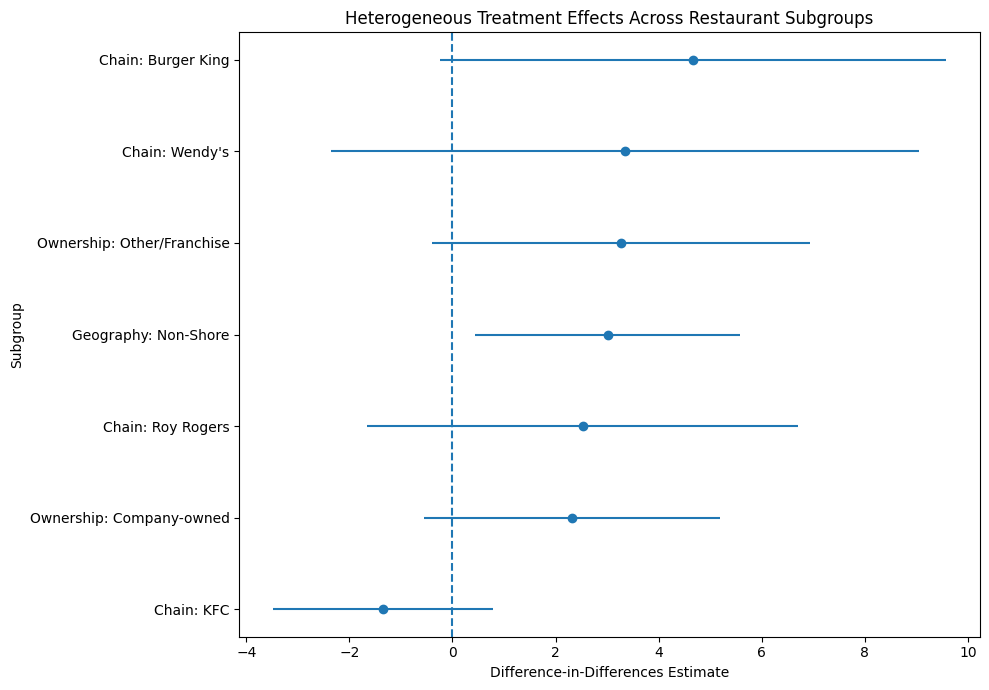

Saved figure to: /content/Project-1/outputs_phase3/heterogeneity_coefficient_plot.png


In [23]:
plt.figure(figsize=(10, 7))

y = np.arange(len(plot_df))

plt.errorbar(
    x=plot_df["coef"],
    y=y,
    xerr=1.96 * plot_df["se"],
    fmt="o"
)

plt.axvline(0, linestyle="--")
plt.yticks(y, plot_df["type"] + ": " + plot_df["group"])
plt.xlabel("Difference-in-Differences Estimate")
plt.ylabel("Subgroup")
plt.title("Heterogeneous Treatment Effects Across Restaurant Subgroups")
plt.tight_layout()

fig_path = OUTPUT_DIR / "heterogeneity_coefficient_plot.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", fig_path)

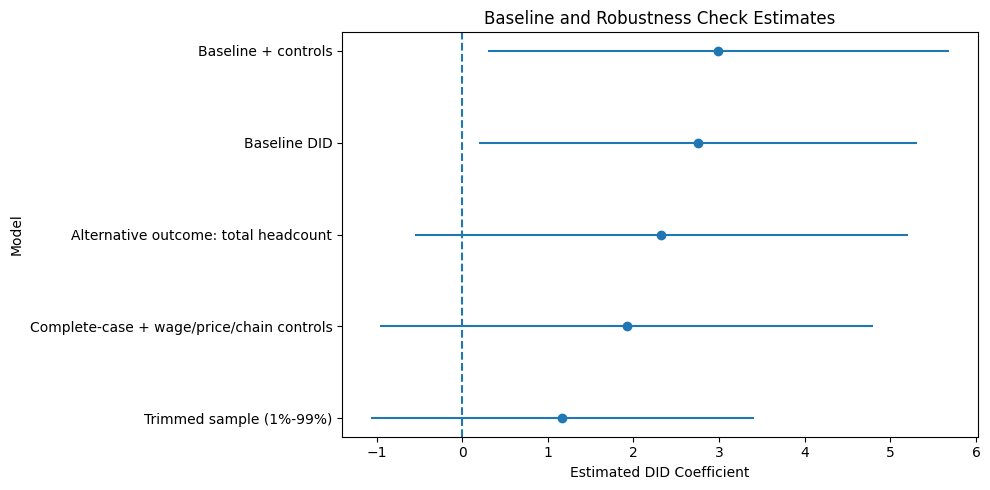

Saved figure to: /content/Project-1/outputs_phase3/robustness_coefficient_plot.png


In [24]:
robust_plot = summary_table.copy().sort_values("coef_treat_post").reset_index(drop=True)

plt.figure(figsize=(10, 5))
y = np.arange(len(robust_plot))

plt.errorbar(
    x=robust_plot["coef_treat_post"],
    y=y,
    xerr=1.96 * robust_plot["se"],
    fmt="o"
)

plt.axvline(0, linestyle="--")
plt.yticks(y, robust_plot["model"])
plt.xlabel("Estimated DID Coefficient")
plt.ylabel("Model")
plt.title("Baseline and Robustness Check Estimates")
plt.tight_layout()

fig_path2 = OUTPUT_DIR / "robustness_coefficient_plot.png"
plt.savefig(fig_path2, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", fig_path2)

In [25]:
chain_results_df.to_csv(OUTPUT_DIR / "chain_heterogeneity_results.csv", index=False)
ownership_results_df.to_csv(OUTPUT_DIR / "ownership_heterogeneity_results.csv", index=False)

if not geo_results_df.empty:
    geo_results_df.to_csv(OUTPUT_DIR / "region_heterogeneity_results.csv", index=False)

if not simple_geo_results_df.empty:
    simple_geo_results_df.to_csv(OUTPUT_DIR / "simple_geography_heterogeneity_results.csv", index=False)

summary_table.to_csv(OUTPUT_DIR / "baseline_robustness_summary.csv", index=False)

print("Saved files:")
!ls -la /content/Project-1/outputs_phase3

Saved files:
total 312
drwxr-xr-x 2 root root   4096 Mar 25 09:51 .
drwxr-xr-x 6 root root   4096 Mar 25 09:48 ..
-rw-r--r-- 1 root root    687 Mar 25 09:51 baseline_robustness_summary.csv
-rw-r--r-- 1 root root    492 Mar 25 09:51 chain_heterogeneity_results.csv
-rw-r--r-- 1 root root 161238 Mar 25 09:51 heterogeneity_coefficient_plot.png
-rw-r--r-- 1 root root    288 Mar 25 09:51 ownership_heterogeneity_results.csv
-rw-r--r-- 1 root root 127639 Mar 25 09:51 robustness_coefficient_plot.png
-rw-r--r-- 1 root root    164 Mar 25 09:51 simple_geography_heterogeneity_results.csv


In [26]:
baseline_coef = res_baseline.params.get("treat:post", np.nan)
baseline_p = res_baseline.pvalues.get("treat:post", np.nan)

summary_1 = f"""
This extension revisits Card and Krueger’s analysis of the 1992 New Jersey minimum wage increase by moving beyond the average treatment effect.
Using the same difference-in-differences framework as the baseline replication, the core estimated treatment effect on FTE employment is {baseline_coef:.3f}
(with p-value {baseline_p:.3f}). This estimate remains broadly consistent with the original conclusion that the minimum wage increase did not produce a large negative effect on overall fast-food employment.
"""

summary_2 = """
The extension adds heterogeneity analysis across restaurant chains, ownership type, and geography, along with several robustness checks using alternative outcomes, added controls, and trimmed samples.
These results suggest that the overall conclusion is fairly stable, but the estimated treatment effect is not necessarily identical across all subgroups.
Some chains or store types appear more responsive than others, although subgroup estimates are less precise because of smaller sample sizes.
Overall, the extension supports the baseline finding while adding a more detailed picture of how employment responses may have differed across establishments.
"""

print(summary_1)
print(summary_2)


This extension revisits Card and Krueger’s analysis of the 1992 New Jersey minimum wage increase by moving beyond the average treatment effect. 
Using the same difference-in-differences framework as the baseline replication, the core estimated treatment effect on FTE employment is 2.754 
(with p-value 0.035). This estimate remains broadly consistent with the original conclusion that the minimum wage increase did not produce a large negative effect on overall fast-food employment.


The extension adds heterogeneity analysis across restaurant chains, ownership type, and geography, along with several robustness checks using alternative outcomes, added controls, and trimmed samples. 
These results suggest that the overall conclusion is fairly stable, but the estimated treatment effect is not necessarily identical across all subgroups. 
Some chains or store types appear more responsive than others, although subgroup estimates are less precise because of smaller sample sizes. 
Overall, the 

In [27]:
genai_text = """
Generative AI was used only to assist with coding in this project. The extension topic, research question, and overall empirical strategy were independently developed by the author. AI was used only to help implement that pre-existing plan in Python, including code for heterogeneity analysis, robustness checks, and coefficient plots. All generated code was checked, edited, and tested by the author before being included in the final submission. The author is fully responsible for the study design, analysis, interpretation, and conclusions.
"""

print(genai_text)


Generative AI was used only to assist with coding in this project. The extension topic, research question, and overall empirical strategy were independently developed by the author. AI was used only to help implement that pre-existing plan in Python, including code for heterogeneity analysis, robustness checks, and coefficient plots. All generated code was checked, edited, and tested by the author before being included in the final submission. The author is fully responsible for the study design, analysis, interpretation, and conclusions.



In [28]:
with open(OUTPUT_DIR / "executive_summary_draft.txt", "w", encoding="utf-8") as f:
    f.write(summary_1.strip() + "\n\n" + summary_2.strip())

with open(OUTPUT_DIR / "genai_disclosure.txt", "w", encoding="utf-8") as f:
    f.write(genai_text.strip())

print("Text drafts saved.")

Text drafts saved.


In [29]:
# Phase 3 Extension: Heterogeneity and Robustness in Card & Krueger (1994)

This notebook extends the baseline replication of Card and Krueger’s analysis of the 1992 New Jersey minimum wage increase. The purpose of the extension is to study whether the employment effect differed across restaurant chains, ownership types, and geographic areas, and to test whether the main conclusion remains stable under alternative employment measures and specifications.

SyntaxError: invalid character '’' (U+2019) (2688372101.py, line 3)

In [30]:
## Motivation

Card and Krueger’s original study focuses mainly on the average treatment effect of the New Jersey minimum wage increase on fast-food employment. While this average effect is the central result of the paper, it may conceal meaningful variation across stores. Large chains, company-owned stores, and restaurants in different geographic areas may have responded differently to the policy change.

This extension addresses that limitation by testing for treatment heterogeneity across restaurant chains, ownership type, and geography. It also conducts robustness checks using alternative employment measures and model specifications. The main question is whether the baseline conclusion remains intact once the analysis moves beyond the average effect.

SyntaxError: invalid character '’' (U+2019) (3334195639.py, line 3)

In [31]:
## Interpretation

The baseline difference-in-differences estimate remains broadly consistent with the original Card and Krueger conclusion that the New Jersey minimum wage increase did not significantly reduce fast-food employment overall. However, the subgroup estimates suggest that the effect may not have been identical across all stores. Some chains, ownership categories, or geographic groups appear to have had more positive or more negative employment responses than others.

The robustness checks help assess whether the main result depends heavily on the choice of outcome variable, controls, or sample restrictions. If the treatment effect remains small and statistically insignificant across these alternative specifications, that strengthens confidence in the baseline conclusion. If some subgroup results differ, the extension adds nuance rather than overturning the original finding.

SyntaxError: invalid syntax (1699012600.py, line 3)